Epoch 001 | tr_loss=1.534 | val_loss=1.464 | val_acc=0.400
Epoch 002 | tr_loss=1.786 | val_loss=1.425 | val_acc=0.400
Epoch 003 | tr_loss=1.606 | val_loss=1.395 | val_acc=0.400
Epoch 004 | tr_loss=1.565 | val_loss=1.372 | val_acc=0.400
Epoch 005 | tr_loss=1.687 | val_loss=1.357 | val_acc=0.400
Epoch 006 | tr_loss=1.611 | val_loss=1.346 | val_acc=0.400
Epoch 007 | tr_loss=1.518 | val_loss=1.340 | val_acc=0.400
Epoch 008 | tr_loss=1.471 | val_loss=1.339 | val_acc=0.400
Epoch 009 | tr_loss=1.392 | val_loss=1.343 | val_acc=0.400
Epoch 010 | tr_loss=1.381 | val_loss=1.344 | val_acc=0.400

[Test] loss=1.441 acc=0.400
              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1

    accuracy                           0.40         5
   macro avg       0.10      0.25      0.14         5
w

/home/hari/eqgc-experiments/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hari/eqgc-experiments/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hari/eqgc-experiments/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

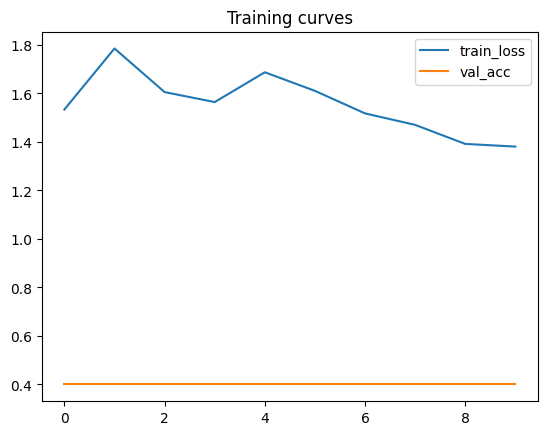

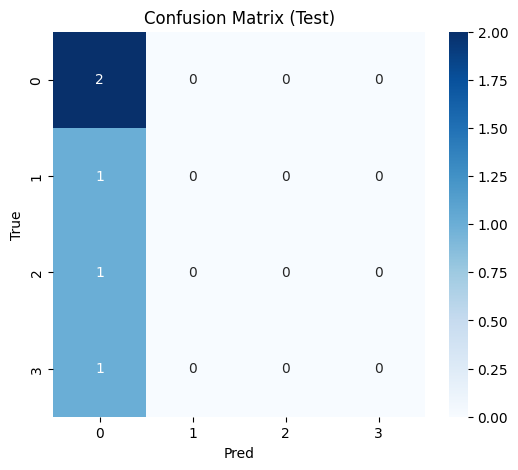

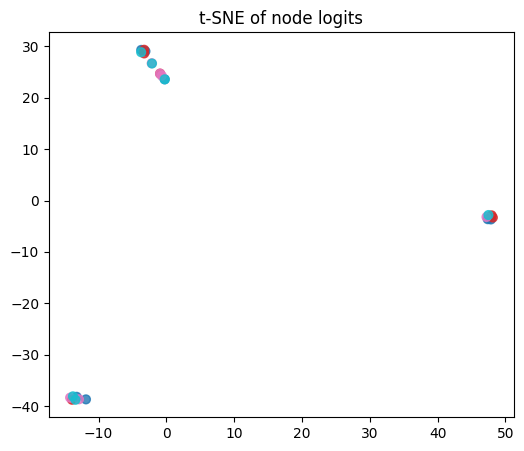

In [1]:
# edu_qgc_synth_node.py
# -*- coding: utf-8 -*-
"""
Node classification experiment on synthetic graph dataset using EDU-QGC.
- Loads synthetic dataset from CSVs (nodes.csv, features.csv, edges.csv, metadata.json)
- Runs node classification with train/val/test splits from dataset
- Keeps EDUQGCNodeClassifier intact
"""

import os, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE

import pennylane as qml
from torch_geometric.data import Data

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# =====================================================
# Reproducibility
# =====================================================
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# =====================================================
# Model (unchanged)
# =====================================================
from torch.nn import Dropout   # only add Dropout wrapper externally if needed

class EDUQGCNodeClassifier(nn.Module):
    def __init__(self, n_nodes, in_feats, T=2, seed=0, use_gpu_qnode=True, use_feat_skip=True, num_classes=7):
        super().__init__()
        self.n_nodes = n_nodes
        self.T = T
        self.use_feat_skip = use_feat_skip

        self.enc_W = nn.Parameter(torch.randn(T, 2, in_feats) * 0.08)
        self.enc_b = nn.Parameter(torch.randn(T, 2) * 0.02)

        self.edge_phase  = nn.Parameter(torch.randn(T) * 0.08)
        self.pre_theta   = nn.Parameter(torch.randn(T) * 0.08)
        self.pre_psi     = nn.Parameter(torch.randn(T) * 0.08)
        self.post_theta  = nn.Parameter(torch.randn(T) * 0.08)
        self.post_psi    = nn.Parameter(torch.randn(T) * 0.08)

        readin_dim = 1 + in_feats if use_feat_skip else 1
        self.readout = nn.Sequential(
            nn.Linear(readin_dim, num_classes),
            Dropout(p=0.3)  # 🔹 dropout for regularization
        )

        use_cuda = torch.cuda.is_available()
        qdev_name = "lightning.gpu" if (use_gpu_qnode and use_cuda) else "default.qubit"
        self.dev = qml.device(qdev_name, wires=n_nodes, shots=None)

        @qml.qnode(self.dev, interface="torch", diff_method="best")
        def circuit(edge_index, X, enc_W, enc_b,
                    edge_phase, pre_theta, pre_psi, post_theta, post_psi):
            for t in range(self.T):
                enc_out = X @ enc_W[t].T + enc_b[t]
                alphas = enc_out[:, 0]; betas = enc_out[:, 1]
                for i in range(self.n_nodes):
                    qml.RX(alphas[i], wires=i)
                    qml.RY(betas[i], wires=i)

                for i in range(self.n_nodes):
                    qml.RZ(pre_psi[t], wires=i)
                    qml.RX(pre_theta[t], wires=i)

                E = edge_index.shape[1]
                for e in range(E):
                    u = int(edge_index[0, e].item()); v = int(edge_index[1, e].item())
                    if u != v:
                        qml.ControlledPhaseShift(edge_phase[t], wires=[u, v])

                for i in range(self.n_nodes):
                    qml.RZ(post_psi[t], wires=i)
                    qml.RX(post_theta[t], wires=i)

            return [qml.expval(qml.Z(i)) for i in range(self.n_nodes)]

        self._circuit = circuit

    def forward(self, edge_index_torch, x_torch):
        device = next(self.parameters()).device
        edge_index = edge_index_torch.to(device)
        X = x_torch.to(device).float()

        out = self._circuit(edge_index, X,
                            self.enc_W, self.enc_b,
                            self.edge_phase,
                            self.pre_theta, self.pre_psi,
                            self.post_theta, self.post_psi)

        expvals = torch.stack(out, dim=0).float().to(device)
        if expvals.dim() == 1:
            expvals = expvals.unsqueeze(1)
        elif expvals.dim() == 2 and expvals.shape[1] == 1:
            pass
        else:
            expvals = expvals.squeeze(-1).unsqueeze(1)

        readin = torch.cat([expvals, X], dim=1) if self.use_feat_skip else expvals
        logits = self.readout(readin)
        return logits

# =====================================================
# Training / Evaluation
# =====================================================

def train_nodeclf(model, data, opt):
    model.train()
    logits = model(data.edge_index, data.x)
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

@torch.no_grad()
def evaluate_nodeclf(model, data, mask):
    model.eval()
    logits = model(data.edge_index, data.x)
    pred = logits.argmax(1)
    loss = F.cross_entropy(logits[mask], data.y[mask]).item()
    acc = accuracy_score(data.y[mask].cpu(), pred[mask].cpu())
    return loss, acc, pred.cpu().numpy(), logits.detach().cpu().numpy()

# =====================================================
# Load synthetic dataset
# =====================================================

# --- inside load_synthetic_graph() ---
from sklearn.model_selection import train_test_split

def load_synthetic_graph(dataset_dir, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, seed=42):
    nodes = pd.read_csv(os.path.join(dataset_dir, "nodes.csv"))
    edges = pd.read_csv(os.path.join(dataset_dir, "edges.csv"))

    # Features
    feature_cols = [c for c in nodes.columns if c not in ["id", "label"]]
    X = nodes[feature_cols]

    # Encode categorical
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    if cat_cols:
        for col in cat_cols:
            le = LabelEncoder()
            X.loc[:, col] = le.fit_transform(X[col].astype(str))

    # Normalize numeric
    num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
    if num_cols:
        scaler = StandardScaler()
        X.loc[:, num_cols] = scaler.fit_transform(X[num_cols])

    feats = X.values.astype(np.float32)

    # Encode labels
    labels = LabelEncoder().fit_transform(nodes["label"])
    labels = torch.tensor(labels, dtype=torch.long)

    edge_index = torch.tensor(edges.values.T, dtype=torch.long)

    data = Data(x=torch.tensor(feats, dtype=torch.float),
                edge_index=edge_index,
                y=labels)

    # --- ✅ stratified train/val/test split ---
    idx = np.arange(len(labels))
    y_np = labels.numpy()

    train_idx, test_idx = train_test_split(idx, stratify=y_np,
                                           test_size=test_ratio,
                                           random_state=seed)
    train_idx, val_idx = train_test_split(train_idx, stratify=y_np[train_idx],
                                          test_size=val_ratio/(train_ratio+val_ratio),
                                          random_state=seed)

    # Masks
    data.train_mask = torch.zeros(len(labels), dtype=torch.bool); data.train_mask[train_idx] = True
    data.val_mask   = torch.zeros(len(labels), dtype=torch.bool); data.val_mask[val_idx] = True
    data.test_mask  = torch.zeros(len(labels), dtype=torch.bool); data.test_mask[test_idx] = True

    with open(os.path.join(dataset_dir, "metadata.json")) as f:
        meta = json.load(f)

    return data, meta




# =====================================================
# Run experiment
# =====================================================
# --- in run_node_classification() ---
from sklearn.utils.class_weight import compute_class_weight

def run_node_classification(dataset_dir, epochs=30, lr=0.03, seed=42):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data, meta = load_synthetic_graph(dataset_dir)
    data = data.to(device)

    N, F, C = data.num_nodes, data.num_features, len(np.unique(data.y.cpu().numpy()))

    model = EDUQGCNodeClassifier(n_nodes=N, in_feats=F, num_classes=C).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # ✅ compute class weights
    y_train = data.y[data.train_mask].cpu().numpy()
    class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    # replace default loss
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    tr_losses, val_accs = [], []
    for ep in range(1, epochs+1):
        model.train()
        logits = model(data.edge_index, data.x)
        loss = loss_fn(logits[data.train_mask], data.y[data.train_mask])
        opt.zero_grad(); loss.backward(); opt.step()

        val_loss, val_acc, _, _ = evaluate_nodeclf(model, data, data.val_mask)
        tr_losses.append(loss.item()); val_accs.append(val_acc)
        print(f"Epoch {ep:03d} | tr_loss={loss.item():.3f} | val_loss={val_loss:.3f} | val_acc={val_acc:.3f}")

    # --- test ---
    te_loss, te_acc, pred, logits = evaluate_nodeclf(model, data, data.test_mask)
    print("\n[Test] loss={:.3f} acc={:.3f}".format(te_loss, te_acc))

    # Metrics
    y_true = data.y[data.test_mask].cpu().numpy()
    print(classification_report(y_true, pred[data.test_mask.cpu().numpy()]))

    # --------- Visualizations ---------
    # 1. Loss/accuracy curves
    plt.figure();
    plt.plot(tr_losses, label="train_loss")
    plt.plot(val_accs, label="val_acc")
    plt.legend(); plt.title("Training curves"); plt.show()

    # 2. Confusion matrix
    cm = confusion_matrix(y_true, pred[data.test_mask.cpu().numpy()])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix (Test)"); plt.xlabel("Pred"); plt.ylabel("True")
    plt.show()

    # 3. t-SNE of logits
    logits_np = logits if isinstance(logits, np.ndarray) else logits
    n_samples = logits_np.shape[0]
    tsne = TSNE(n_components=2, random_state=seed, perplexity=min(5, n_samples-1))
    emb = tsne.fit_transform(logits_np)

    plt.figure(figsize=(6,5))
    plt.scatter(emb[:,0], emb[:,1], c=data.y.cpu(), cmap="tab10", s=40, alpha=0.8)
    plt.title("t-SNE of node logits")
    plt.show()

    return dict(test_acc=te_acc, test_loss=te_loss)

if __name__=="__main__":
    run_node_classification("./synthetic_graph_data", epochs=10)


In [2]:
import numpy as np
import torch

unique, counts = np.unique(data.y.cpu().numpy(), return_counts=True)
print(dict(zip(unique, counts)))


NameError: name 'data' is not defined